In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import torch
from tqdm import tqdm 
from models.scs import * 
from metrics import treatment_effect

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load PEACE dataset
from datasets_retrospective import load_peace_dataset
outcomes, features, intervention, cat_feats, num_feats = load_peace_dataset(location='datasets/PEACE/Data/', outcome='PRIMARY')

(8290, 7)
(8290, 39)
(8290, 7)
(8290, 39)


In [4]:
# # Specify categorical and numeric features used for training the model
cat_feats=['Sex', 'Baseline_Smoke_status', 'Baseline_History_Insulin']
num_feats=['Baseline_Age', 'Baseline_Seated_Systolic_Blood_Pressure', 'Baseline_Seated_Diastolic_Blood_Pressure']

In [5]:
# Preprocess feature data
from preprocessing import Preprocessor
features = Preprocessor().fit_transform(data=features[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [6]:
features

,Baseline_Age,Baseline_Seated_Systolic_Blood_Pressure,Baseline_Seated_Diastolic_Blood_Pressure,Sex_Male,Baseline_Smoke_status_Ever,Baseline_Smoke_status_Never
NEW_ID,,,,,,
10007.0,-0.772874,1.364896,0.570418,1,0,1
10026.0,0.447554,0.880148,1.712760,1,1,0
10027.0,0.081426,-0.755875,-0.468074,1,1,0
10040.0,-0.040617,0.758962,0.778117,1,0,1
10042.0,-0.406746,-0.089347,0.362720,1,0,1
...,...,...,...,...,...,...
99957.0,2.278197,3.000919,2.543553,1,1,0
99959.0,-0.284703,0.153027,-1.091169,1,1,0
99968.0,1.790026,0.455994,0.570418,1,1,0


In [10]:
from models.scs.model import SparseCoxSubgroup

# Hyper-parameters to train model
k = 2 # number of underlying base survival phenotypes
random_seed = 3
n_epochs = 2000 # number of training epochs
step_size = 1e-5


torch.manual_seed(random_seed)
np.random.seed(random_seed)


# Instantiate the CMHE model on all data
model = SparseCoxSubgroup(k=k, random_seed=random_seed, n_epochs=n_epochs, n_restarts=1, step_size=step_size, alpha=0.)

model.fit(features.values, outcomes.time.values, outcomes.event.values, (intervention=='Trandolapril').values)

Restarts:   0%|          | 0/1 [00:00<?, ?it/s]

2.659577005648174
2.649660369535666
2.6444054224221425
2.6406714907826854
2.637521854419626
2.6252814038621977
2.6224585027136635
2.6135766488050267
2.6091411388978414
2.606984584241855
2.6044988407511704


2.6018703951070985
2.5953724655827815
2.595198634102054
2.588113408904705
2.5874544713917964
2.5848371054875003
2.5811920210923063
2.577391070110461
2.5738360184039917
2.572164507108972


2.5715183480824932
2.5689602751917873
2.5648196170554503
2.5673554139478387
2.5649723770054327
2.5608486268419095
2.5603494210961393
2.5615286863316378
2.5605857980814357
2.55817194520249


2.555679915605732
2.552727691740578
2.556279444560629
2.5505726531473663
2.5544314076607004
2.5493842222994165
2.546948288510623
2.542361161552654
2.5435309142809928
2.543644806363907


...

2.471190057507227
2.4711873930701076
2.4711883694344774
2.4712089518821854
2.471193866862714
2.4712035539581523
2.471202672990177
2.471185848361216
2.471177976152124
2.471176532519097


2.471198504681642
2.471191739291453
2.4711745517817043
2.4711550231408492
2.4712354091590774
2.471197744506311
2.4711799761572415
2.4711869923165417
2.471176524483183


2.471177975708671
2.471148354887172
2.471238084491247
2.4711894223680853
2.4711905954380877
2.4711814998001738
2.471178889401304
2.4711923373609457
2.4712112184214


Restarts: 100%|██████████| 1/1 [00:53<00:00, 53.73s/it]

2.4711617231012077
2.4711462976597245


In [11]:
model.parameters['gate']

tensor([[0.0541, 0.0557],
        [0.1552, 0.1576],
        [0.2664, 0.2654],
        [0.7569, 0.7586],
        [0.7408, 0.7415],
        [0.6252, 0.6253]], requires_grad=True)

In [12]:
zeta = model.predict_proba(features.values).argmax(axis=1)

In [42]:
# zeta_probs = model.predict_proba(features.values)
# zeta = np.argmax(zeta_probs, axis=1)

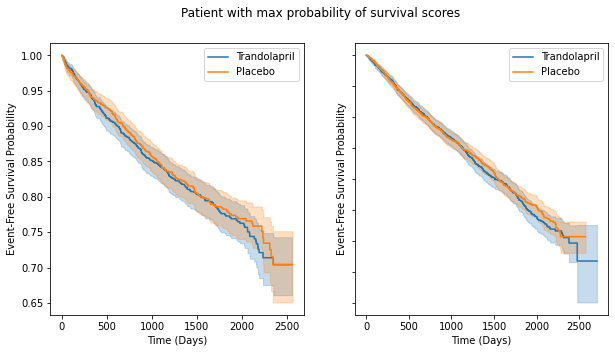

In [13]:
from matplotlib import pyplot as plt

from auton_survival import reporting
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Patient with max probability of survival scores')
reporting.plot_kaplanmeier(outcomes[zeta == 0], intervention[zeta == 0], ax=ax1)
reporting.plot_kaplanmeier(outcomes[zeta == 1], intervention[zeta == 1], ax=ax2)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.show()

In [44]:
from sklearn.model_selection import train_test_split

# Split the PEACE data into training and test data
x_train, x_test, y_train, y_test = train_test_split(features, outcomes, test_size=0.3, random_state=1, 
                                          stratify = outcomes.event + 2*(intervention=='Trandolapril'))

print(f'Number of training data points: {len(x_train)}')
print(f'Number of test data points: {len(x_test)}')

Number of training data points: 5803
Number of test data points: 2487


In [45]:
x_tr = x_train.values
t_tr = y_train['time'].values
e_tr = y_train['event'].values
a_tr = intervention[y_train.index]=='Trandolapril'

x_te = x_test.values
t_te = y_test['time'].values
e_te = y_test['event'].values
a_te = (intervention[y_test.index]=='Trandolapril').values

In [46]:
from models.scs.model import SparseCoxSubgroup

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model on all data
model = SparseCoxSubgroup(k=k, random_seed=random_seed, n_epochs=n_epochs, n_restarts=1, step_size=step_size, alpha=0.)

model.fit(x_tr, t_tr, e_tr, a_tr)

Restarts:   0%|          | 0/1 [00:00<?, ?it/s]

2.5077680967697655
2.4999781894525364
2.5003878036547786
2.489509724799053
2.4894862374680558
2.487051633629287
2.484145416916593
2.4772919210814686
2.4779760233661157
2.472833545944278
2.4724356700113654
2.4624382261950064
2.4658441251336654


2.4635859124359034
2.4600561468459254
2.458966027349812
2.454466191958982
2.455009045302024
2.4543669095636043
2.4517877133689314
2.4462073340595296
2.446916893436308
2.4478479076401736
2.4441472824452735
2.446204902480052


2.443645585726969
2.4456041334999927
2.442301528460781
2.439083817439923
2.4428577984870863
2.4414640563373804
2.43837858397032
2.4393835297323996
2.4392181446112224
2.4352617451014935
2.436567495075914
2.4378363733585435


2.4341577910793517
2.4339883404829834
2.4342135743386284
2.4342998376288065
2.4328834250433227
2.4358073112525056
2.4324386671352984
2.4311588280784178
2.4316394544231548
2.43108063463527
2.433829502686767
2.4299942770068994


...

2.3896222167016328
2.389567003097972
2.389621373494704
2.3895848068087533
2.389623225183953
2.389591130720855
2.389601792140128
2.3895988770344267
2.3894894387905294
2.3895197352181876
2.3894762648573704
2.389509989489023


2.3896567456475797
2.3895395938081774
2.389472293411943
2.3894517886063014
2.3894629958716616
2.3896357585731183
2.3895782313697613
2.389633330697758
2.3896883985278996
2.3896089648579166
2.3894746405885634
2.3894387109487587


2.389474316256281
2.389545119399813
2.3896358354973875
2.3895133164700995
2.389507506012932
2.389554401992296
2.3894804522584
2.3894669360867007
2.3895973188525
2.389514863499702
2.389444118206246
2.3895186633884
2.3895529806635


Restarts: 100%|██████████| 1/1 [00:37<00:00, 37.84s/it]

2.3894610565238645
2.3894836629468625
2.3896867057355307
2.3894054987629714
2.389547519539999
2.389569906936176
2.3895575967452
2.389353182887512
2.38954207571713


In [47]:
zeta_probs_train = model.predict_proba(x_tr)
zeta_train =  np.argmax(zeta_probs_train, axis=1)

zeta_probs_test = model.predict_proba(x_te)
zeta_test =  np.argmax(zeta_probs_test, axis=1)

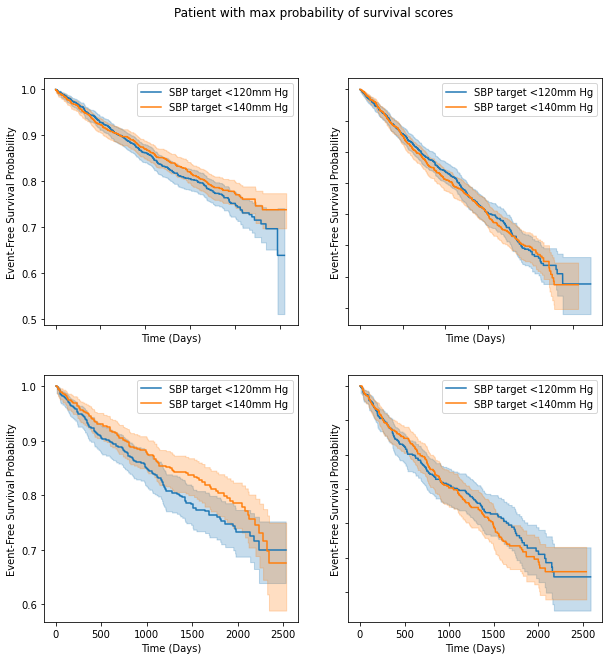

In [49]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize= (10, 10))
fig.suptitle('Patient with max probability of survival scores')
reporting.plot_kaplanmeier(y_train[zeta_train == 0], a_tr[zeta_train == 0], ax=ax1)
reporting.plot_kaplanmeier(y_train[zeta_train == 1], a_tr[zeta_train == 1], ax=ax2)
reporting.plot_kaplanmeier(y_test[zeta_test == 0], a_te[zeta_test == 0], ax=ax3) 
reporting.plot_kaplanmeier(y_test[zeta_test == 1], a_te[zeta_test == 1], ax=ax4)
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['SBP target <120mm Hg', 'SBP target <140mm Hg'], loc="upper right")
plt.show()
# First row is training data
# Second row is test data
# First column is zeta 0
# Second column is zeta 1